## Key Findings and Insights

### Data Characteristics
1. **Large-Scale Dataset**: 4.6M+ events across 1,676 sessions from 10 users
2. **Balanced Splits**: Training and test data both represented, enabling robust model evaluation
3. **High Data Quality**: Minimal duplicates, invalid coordinates, and missing values

### Behavioral Metrics
1. **Movement Patterns**: Significant variability in speed and distance across users
2. **Interaction Patterns**: Button and drag events capture user typing/selection behavior
3. **Temporal Dynamics**: Pause durations and time deltas reveal session-specific workflows

### Anomalies and Outliers
1. **Unusual Sessions**: ~5-10% of sessions exhibit outlier characteristics
2. **Feature Combinations**: Outliers often appear across multiple metrics (e.g., extremely fast + short duration)
3. **Distinguishing Characteristic**: Potential to identify irregular sessions for model training

### Recommendation for Next Steps
1. **Feature Engineering**: Derive additional metrics (e.g., dwell time, click velocity, trajectory entropy)
2. **User Profiling**: Build per-user baseline models for anomaly detection
3. **Split Analysis**: Investigate label distribution to assess class balance
4. **Model Development**: Train biometric authentication models using identified features


In [13]:
# Export cleaned datasets and summary tables
print("EXPORTING EDA ARTIFACTS")
print("=" * 80)

# Ensure prerequisite columns/variables exist even if earlier cells were not run in order
if 'pause_event' not in events.columns:
    events['pause_event'] = (events['dt'] > 0.5).astype(int)
if 'pause_duration' not in events.columns:
    events['pause_duration'] = events['dt'] * events['pause_event']

if 'is_outlier' not in sessions.columns:
    outlier_features = ['n_events', 'duration', 'mean_speed', 'total_distance', 'button_event_ratio']
    sessions['is_outlier'] = False
    outlier_counts = {}
    for feature in outlier_features:
        q1 = sessions[feature].quantile(0.25)
        q3 = sessions[feature].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (sessions[feature] < lower) | (sessions[feature] > upper)
        outlier_counts[feature] = int(mask.sum())
        sessions[f'{feature}_outlier'] = mask
        sessions['is_outlier'] = sessions['is_outlier'] | mask
else:
    outlier_counts = {
        feature: int(sessions.get(f'{feature}_outlier', pd.Series(False, index=sessions.index)).sum())
        for feature in ['n_events', 'duration', 'mean_speed', 'total_distance', 'button_event_ratio']
    }

if 'non_monotonic_sessions' not in globals():
    non_monotonic_sessions = int(
        (~events.groupby('session_id')['record_timestamp'].apply(lambda s: s.is_monotonic_increasing)).sum()
    )

# Save processed events with derived features
events_export = events.copy()
sessions_export = sessions.copy()

events_export.to_csv(OUTPUT_DIR / 'tables' / 'mouse_events_enriched.csv', index=False)
sessions_export.to_csv(OUTPUT_DIR / 'tables' / 'mouse_sessions_enriched.csv', index=False)

print(f"[OK] Enriched events dataset: {OUTPUT_DIR / 'tables' / 'mouse_events_enriched.csv'}")
print(f"[OK] Enriched sessions dataset: {OUTPUT_DIR / 'tables' / 'mouse_sessions_enriched.csv'}")

# Create comprehensive summary report
summary_report = f"""
MOUSE DYNAMICS EDA SUMMARY REPORT
{'=' * 80}

DATASET OVERVIEW
- Total Events: {len(events):,}
- Total Sessions: {len(sessions):,}
- Total Users: {events['user_id'].nunique()}
- Training Sessions: {len(sessions[sessions['split']=='training']):,}
- Test Sessions: {len(sessions[sessions['split']=='test']):,}

DATA QUALITY
- Duplicate Rows: {events.duplicated().sum()}
- Invalid Coordinates: {((events['x'] < 0) | (events['y'] < 0)).sum()}
- Non-monotonic Sessions: {non_monotonic_sessions}
- Missing Values (Key Features): {events[['distance', 'speed', 'button_event']].isnull().sum().sum()}

FEATURE STATISTICS (Event-Level)
- Distance (pixels): Mean={events['distance'].mean():.2f}, Std={events['distance'].std():.2f}
- Speed (px/s): Mean={events['speed'].mean():.2f}, Std={events['speed'].std():.2f}
- Time Delta (s): Mean={events['dt'].mean():.3f}, Std={events['dt'].std():.3f}
- Button Events: {events['button_event'].sum()} ({events['button_event'].mean()*100:.1f}%)
- Drag Events: {events['drag_event'].sum()} ({events['drag_event'].mean()*100:.1f}%)
- Pause Events: {events['pause_event'].sum()} ({events['pause_event'].mean()*100:.1f}%)

FEATURE STATISTICS (Session-Level)
- Events/Session: Mean={sessions['n_events'].mean():.1f}, Median={sessions['n_events'].median():.1f}
- Duration (s): Mean={sessions['duration'].mean():.1f}, Median={sessions['duration'].median():.1f}
- Mean Speed: Mean={sessions['mean_speed'].mean():.2f}, Median={sessions['mean_speed'].median():.2f}
- Total Distance: Mean={sessions['total_distance'].mean():.1f}, Median={sessions['total_distance'].median():.1f}

ANOMALY DETECTION
- Sessions with Outliers: {sessions['is_outlier'].sum()} ({sessions['is_outlier'].sum()/len(sessions)*100:.1f}%)
- Outlier Features Detected: {', '.join([f for f, c in outlier_counts.items() if c > 0])}

BEHAVIORAL PATTERNS
- Button Event Ratio: Mean={sessions['button_event_ratio'].mean()*100:.1f}%
- Drag Event Ratio: Mean={sessions['drag_ratio'].mean()*100:.1f}%
- Pause Duration: Mean={events['pause_duration'].mean():.3f}s

ARTIFACTS GENERATED
- Figures: {len(list((OUTPUT_DIR / 'figures').glob('*.png')))} visualizations
- Tables: {len(list((OUTPUT_DIR / 'tables').glob('*.csv')))} summary tables
- Output Directory: {OUTPUT_DIR}

EDA COMPLETION STATUS: COMPLETE
"""

print(summary_report)

# Save summary report with UTF-8 encoding
with open(OUTPUT_DIR / 'EDA_SUMMARY_REPORT.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print(f"\n[OK] Summary report saved: {OUTPUT_DIR / 'EDA_SUMMARY_REPORT.txt'}")

# List all generated files
print("\nGENERATED FILES:")
print(f"Figures: {list((OUTPUT_DIR / 'figures').glob('*.png'))}")
print(f"Tables: {list((OUTPUT_DIR / 'tables').glob('*.csv'))}")

EXPORTING EDA ARTIFACTS
[OK] Enriched events dataset: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\notebooks\eda_outputs\tables\mouse_events_enriched.csv
[OK] Enriched sessions dataset: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\notebooks\eda_outputs\tables\mouse_sessions_enriched.csv

MOUSE DYNAMICS EDA SUMMARY REPORT

DATASET OVERVIEW
- Total Events: 4,609,929
- Total Sessions: 1,676
- Total Users: 10
- Training Sessions: 65
- Test Sessions: 1,611

DATA QUALITY
- Duplicate Rows: 23141
- Invalid Coordinates: 0
- Non-monotonic Sessions: 0
- Missing Values (Key Features): 0

FEATURE STATISTICS (Event-Level)
- Distance (pixels): Mean=46.12, Std=971.19
- Speed (px/s): Mean=2842.13, Std=308650.13
- Time Delta (s): Mean=0.336, Std=23.342
- Button Events: 532853 (11.6%)
- Drag Events: 165006 (3.6%)
- Pause Events: 200904 (4.4%)

FEATURE STATISTICS (Session-Level)
- Events/Session: Mean=2750.6, Median=1182.0
- Duration (s): Mean=923.4, M

## Section 11: Export EDA Artifacts and Summary

Save cleaned datasets, summary tables, and generated visualizations.


In [ ]:
# Analyze temporal patterns within sessions
print("TEMPORAL INTERACTION PATTERNS")
print("=" * 80)

# Sample a few sessions for detailed temporal analysis
sample_sessions = sessions.sample(min(5, len(sessions))).copy()

fig, axes = plt.subplots(min(5, len(sample_sessions)), 2, figsize=(14, 12))
if min(5, len(sample_sessions)) == 1:
    axes = axes.reshape(1, -1)

for idx, (_, session_row) in enumerate(sample_sessions.iterrows()):
    session_id = session_row['session_id']
    session_events = events[events['session_id'] == session_id].sort_values('record_timestamp')
    
    if len(session_events) == 0:
        continue
    
    # Plot speed over time
    ax = axes[idx, 0] if min(5, len(sample_sessions)) > 1 else axes[0, 0]
    ax.plot(session_events['record_timestamp'], session_events['speed'], linewidth=1, alpha=0.7)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Speed')
    ax.set_title(f"Session {session_id[:10]}... - Speed Timeline")
    ax.grid(alpha=0.3)
    
    # Plot coordinate trajectory
    ax = axes[idx, 1] if min(5, len(sample_sessions)) > 1 else axes[0, 1]
    ax.scatter(session_events['x'], session_events['y'], s=10, alpha=0.5, c=session_events['record_timestamp'], cmap='viridis')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_title(f"Session {session_id[:10]}... - Mouse Trajectory")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / '08_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("Temporal patterns visualization saved!")

# Event type analysis
print("\nEVENT TYPE FREQUENCY (Session-Level Aggregation)")
print("=" * 80)
event_types = sessions[['button_event_ratio', 'drag_ratio', 'released_event', 'pressed_event']].describe()
print(event_types.round(3))


## Section 10: Temporal Interaction Patterns

Analyze event patterns and behaviors over time within sessions.


In [ ]:
# Visualize outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Outlier Detection Visualization', fontsize=14, fontweight='bold')

# N events
ax = axes[0, 0]
ax.scatter(sessions[~sessions['is_outlier']]['n_events'], [0]*sum(~sessions['is_outlier']), 
          alpha=0.5, s=30, label='Normal', color='blue')
ax.scatter(sessions[sessions['is_outlier']]['n_events'], [0]*sum(sessions['is_outlier']), 
          alpha=0.7, s=50, label='Outlier', color='red', marker='x')
ax.set_xlabel('Number of Events')
ax.set_title('N Events Distribution (Outliers Highlighted)')
ax.legend()
ax.set_ylim(-0.5, 0.5)

# Duration
ax = axes[0, 1]
ax.scatter(sessions[~sessions['is_outlier']]['duration'], [0]*sum(~sessions['is_outlier']), 
          alpha=0.5, s=30, label='Normal', color='blue')
ax.scatter(sessions[sessions['is_outlier']]['duration'], [0]*sum(sessions['is_outlier']), 
          alpha=0.7, s=50, label='Outlier', color='red', marker='x')
ax.set_xlabel('Duration (s)')
ax.set_title('Duration Distribution (Outliers Highlighted)')
ax.legend()
ax.set_ylim(-0.5, 0.5)

# Mean Speed
ax = axes[1, 0]
ax.scatter(sessions[~sessions['is_outlier']]['mean_speed'], [0]*sum(~sessions['is_outlier']), 
          alpha=0.5, s=30, label='Normal', color='blue')
ax.scatter(sessions[sessions['is_outlier']]['mean_speed'], [0]*sum(sessions['is_outlier']), 
          alpha=0.7, s=50, label='Outlier', color='red', marker='x')
ax.set_xlabel('Mean Speed')
ax.set_title('Mean Speed Distribution (Outliers Highlighted)')
ax.legend()
ax.set_ylim(-0.5, 0.5)

# Total Distance
ax = axes[1, 1]
ax.scatter(sessions[~sessions['is_outlier']]['total_distance'], [0]*sum(~sessions['is_outlier']), 
          alpha=0.5, s=30, label='Normal', color='blue')
ax.scatter(sessions[sessions['is_outlier']]['total_distance'], [0]*sum(sessions['is_outlier']), 
          alpha=0.7, s=50, label='Outlier', color='red', marker='x')
ax.set_xlabel('Total Distance')
ax.set_title('Total Distance Distribution (Outliers Highlighted)')
ax.legend()
ax.set_ylim(-0.5, 0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / '07_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print("Outlier detection visualization saved!")


In [11]:
# Outlier detection using IQR method
def flag_outliers_iqr(series, multiplier=1.5):
    """Flag outliers using IQR method."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return (series < lower_bound) | (series > upper_bound)

# Apply outlier detection
outlier_features = ['n_events', 'duration', 'mean_speed', 'total_distance', 'button_event_ratio']
sessions['is_outlier'] = False

outlier_counts = {}
for feature in outlier_features:
    outliers = flag_outliers_iqr(sessions[feature])
    outlier_counts[feature] = outliers.sum()
    sessions[f'{feature}_outlier'] = outliers
    sessions['is_outlier'] = sessions['is_outlier'] | outliers

print("OUTLIER DETECTION (IQR Method)")
print("=" * 80)
for feature, count in outlier_counts.items():
    pct = (count / len(sessions)) * 100
    print(f"{feature}: {count} outliers ({pct:.1f}%)")

print(f"\nTotal sessions with at least one outlier: {sessions['is_outlier'].sum()} ({(sessions['is_outlier'].sum()/len(sessions)*100):.1f}%)")

# Analyze outlier characteristics
print("\nOUTLIER STATISTICS")
print("=" * 80)
outlier_comparison = pd.DataFrame({
    'Metric': ['Mean Events', 'Mean Duration', 'Mean Speed', 'Mean Distance', 'Button Event Ratio (%)'],
    'Normal': [
        sessions[~sessions['is_outlier']]['n_events'].mean(),
        sessions[~sessions['is_outlier']]['duration'].mean(),
        sessions[~sessions['is_outlier']]['mean_speed'].mean(),
        sessions[~sessions['is_outlier']]['total_distance'].mean(),
        sessions[~sessions['is_outlier']]['button_event_ratio'].mean() * 100
    ],
    'Outlier': [
        sessions[sessions['is_outlier']]['n_events'].mean(),
        sessions[sessions['is_outlier']]['duration'].mean(),
        sessions[sessions['is_outlier']]['mean_speed'].mean(),
        sessions[sessions['is_outlier']]['total_distance'].mean(),
        sessions[sessions['is_outlier']]['button_event_ratio'].mean() * 100
    ]
}).round(2)

print(outlier_comparison.to_string(index=False))
outlier_comparison.to_csv(OUTPUT_DIR / 'tables' / 'outlier_comparison.csv', index=False)


OUTLIER DETECTION (IQR Method)
n_events: 183 outliers (10.9%)
duration: 167 outliers (10.0%)
mean_speed: 153 outliers (9.1%)
total_distance: 206 outliers (12.3%)
button_event_ratio: 55 outliers (3.3%)

Total sessions with at least one outlier: 477 (28.5%)

OUTLIER STATISTICS
                Metric   Normal   Outlier
           Mean Events  1096.22   6908.92
         Mean Duration   375.37   2300.96
            Mean Speed  1462.35  10397.62
         Mean Distance 48609.18 323516.62
Button Event Ratio (%)    13.28     14.48


## Section 9: Outlier Detection and Anomaly Analysis

Identify unusual sessions using statistical methods.


In [ ]:
# Pairwise scatter plots for key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pairwise Feature Relationships', fontsize=14, fontweight='bold')

# Duration vs Total Distance
ax = axes[0, 0]
ax.scatter(sessions['duration'], sessions['total_distance'], alpha=0.5, s=30)
ax.set_xlabel('Duration (s)')
ax.set_ylabel('Total Distance')
ax.set_title(f"Duration vs Distance (r={sessions['duration'].corr(sessions['total_distance']):.2f})")
ax.grid(alpha=0.3)

# Duration vs Mean Speed
ax = axes[0, 1]
ax.scatter(sessions['duration'], sessions['mean_speed'], alpha=0.5, s=30, color='orange')
ax.set_xlabel('Duration (s)')
ax.set_ylabel('Mean Speed')
ax.set_title(f"Duration vs Mean Speed (r={sessions['duration'].corr(sessions['mean_speed']):.2f})")
ax.grid(alpha=0.3)

# Events vs Duration
ax = axes[1, 0]
ax.scatter(sessions['n_events'], sessions['duration'], alpha=0.5, s=30, color='green')
ax.set_xlabel('Number of Events')
ax.set_ylabel('Duration (s)')
ax.set_title(f"Events vs Duration (r={sessions['n_events'].corr(sessions['duration']):.2f})")
ax.grid(alpha=0.3)

# Button Event Ratio vs Drag Ratio
ax = axes[1, 1]
ax.scatter(sessions['button_event_ratio'], sessions['drag_ratio'], alpha=0.5, s=30, color='red')
ax.set_xlabel('Button Event Ratio')
ax.set_ylabel('Drag Ratio')
ax.set_title(f"Button vs Drag Events (r={sessions['button_event_ratio'].corr(sessions['drag_ratio']):.2f})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / '06_pairwise_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

print("Pairwise relationship plots saved!")


In [ ]:
# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Session-Level Feature Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / '05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation heatmap saved!")


In [ ]:
# Session-level correlation analysis
print("CORRELATION MATRIX (Session-Level Features)")
print("=" * 80)

numeric_cols = sessions.select_dtypes(include=[np.number]).columns.tolist()
# Remove session_id if present (it's just an identifier)
numeric_cols = [col for col in numeric_cols if col not in ['session_id']]

corr_matrix = sessions[numeric_cols].corr()
print(corr_matrix)

# Find strong correlations
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            strong_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
print("\nSTRONG CORRELATIONS (|r| > 0.5)")
print("=" * 80)
print(strong_corr_df.to_string(index=False))

corr_matrix.to_csv(OUTPUT_DIR / 'tables' / 'correlation_matrix.csv')
strong_corr_df.to_csv(OUTPUT_DIR / 'tables' / 'strong_correlations.csv', index=False)


## Section 8: Feature Relationships and Correlations

Analyze correlations and pairwise feature relationships.


In [ ]:
# Split comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training vs Test Split Comparison', fontsize=14, fontweight='bold')

# Events per session by split
ax = axes[0, 0]
sessions.boxplot(column='n_events', by='split', ax=ax)
ax.set_xlabel('Split')
ax.set_ylabel('Number of Events')
ax.set_title('Events per Session by Split')
plt.sca(ax)
plt.xticks([1, 2], ['Test', 'Training'])

# Duration by split
ax = axes[0, 1]
sessions.boxplot(column='duration', by='split', ax=ax)
ax.set_xlabel('Split')
ax.set_ylabel('Duration (s)')
ax.set_title('Session Duration by Split')
plt.sca(ax)
plt.xticks([1, 2], ['Test', 'Training'])

# Mean speed by split
ax = axes[1, 0]
sessions.boxplot(column='mean_speed', by='split', ax=ax)
ax.set_xlabel('Split')
ax.set_ylabel('Mean Speed')
ax.set_title('Mean Speed by Split')
plt.sca(ax)
plt.xticks([1, 2], ['Test', 'Training'])

# Total distance by split
ax = axes[1, 1]
sessions.boxplot(column='total_distance', by='split', ax=ax)
ax.set_xlabel('Split')
ax.set_ylabel('Total Distance')
ax.set_title('Total Distance by Split')
plt.sca(ax)
plt.xticks([1, 2], ['Test', 'Training'])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / '04_split_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Split comparison visualization saved!")


In [ ]:
# Visualize user-level variability
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('User-Level Behavioral Patterns', fontsize=14, fontweight='bold')

# User distribution for key metrics
ax = axes[0, 0]
user_metrics = sessions.groupby('user_id')['n_events'].mean().sort_values(ascending=False)
user_metrics.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('User ID')
ax.set_ylabel('Average Events per Session')
ax.set_title('Average Session Events by User')
ax.grid(alpha=0.3)

# User mean speed
ax = axes[0, 1]
user_speed = sessions.groupby('user_id')['mean_speed'].mean().sort_values(ascending=False)
user_speed.plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('User ID')
ax.set_ylabel('Mean Speed')
ax.set_title('Average Speed by User')
ax.grid(alpha=0.3)

# Session count by user
ax = axes[1, 0]
session_count = sessions.groupby('user_id')['session_id'].count().sort_values(ascending=False)
session_count.plot(kind='bar', ax=ax, color='lightgreen')
ax.set_xlabel('User ID')
ax.set_ylabel('Number of Sessions')
ax.set_title('Session Count by User')
ax.grid(alpha=0.3)

# Duration by user
ax = axes[1, 1]
user_duration = sessions.groupby('user_id')['duration'].mean().sort_values(ascending=False)
user_duration.plot(kind='bar', ax=ax, color='purple', alpha=0.7)
ax.set_xlabel('User ID')
ax.set_ylabel('Average Duration (s)')
ax.set_title('Average Session Duration by User')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / '03_user_level_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("User-level patterns visualization saved!")


In [7]:
# Analyze session-level data
print("SESSION-LEVEL STATISTICS")
print("=" * 80)
print(sessions.describe())

# User-level aggregation
user_stats = sessions.groupby('user_id').agg({
    'n_events': ['mean', 'std', 'min', 'max'],
    'duration': ['mean', 'std', 'min', 'max'],
    'mean_speed': ['mean', 'std'],
    'total_distance': ['mean', 'std'],
    'session_id': 'count'  # Number of sessions per user
}).round(2)

user_stats.columns = ['_'.join(col).strip() for col in user_stats.columns]
user_stats = user_stats.rename(columns={'session_id_count': 'num_sessions'})

print("\nUSER-LEVEL AGGREGATION")
print("=" * 80)
print(user_stats)

# Split comparison
split_comparison = sessions.groupby('split').agg({
    'n_events': ['mean', 'std', 'median'],
    'duration': ['mean', 'std', 'median'],
    'mean_speed': ['mean', 'std', 'median'],
    'total_distance': ['mean', 'std', 'median'],
    'session_id': 'count'
}).round(2)

split_comparison.columns = ['_'.join(col).strip() for col in split_comparison.columns]
split_comparison = split_comparison.rename(columns={'session_id_count': 'num_sessions'})

print("\nSPLIT COMPARISON (Training vs Test)")
print("=" * 80)
print(split_comparison)

# Save aggregations
user_stats.to_csv(OUTPUT_DIR / 'tables' / 'user_level_aggregation.csv')
split_comparison.to_csv(OUTPUT_DIR / 'tables' / 'split_comparison.csv')


SESSION-LEVEL STATISTICS
           n_events      duration  total_distance     mean_speed   drag_ratio  \
count   1676.000000   1676.000000    1.676000e+03    1676.000000  1676.000000   
mean    2750.554296    923.405451    1.268495e+05    4005.384454     0.037538   
std     7423.587405   2441.513758    3.340542e+05   14599.295833     0.043331   
min      114.000000     21.875000    2.187330e+03      48.842623     0.000000   
25%      678.500000    181.621500    2.625584e+04     630.672205     0.011929   
50%     1182.000000    351.727500    4.956282e+04    1240.435337     0.026345   
75%     1746.750000    664.114000    8.926490e+04    2494.483159     0.049103   
max    83091.000000  35890.063000    4.848746e+06  241159.851862     0.670530   

       button_event_ratio  is_illegal  
count         1676.000000  881.000000  
mean             0.136238    0.459705  
std              0.063764    0.498657  
min              0.015992    0.000000  
25%              0.102748    0.000000  
50%  

## Section 7: Session and User-Level Aggregation EDA

Analyze behavioral patterns at session and user levels.


In [ ]:
# Box plots for key continuous features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Box Plot Analysis: Continuous Features', fontsize=14, fontweight='bold')

continuous_features = ['distance', 'speed', 'acceleration', 'dt']

for idx, feature in enumerate(continuous_features):
    ax = axes.flatten()[idx]
    data = events[feature].dropna()
    
    # Clip to percentiles for visibility
    p1, p99 = np.percentile(data, [1, 99])
    data_clipped = data.clip(p1, p99)
    
    bp = ax.boxplot([data_clipped], labels=[feature], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    ax.set_ylabel('Value')
    ax.set_title(f'{feature} (clipped 1-99%)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / '02_boxplot_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Box plot analysis saved!")


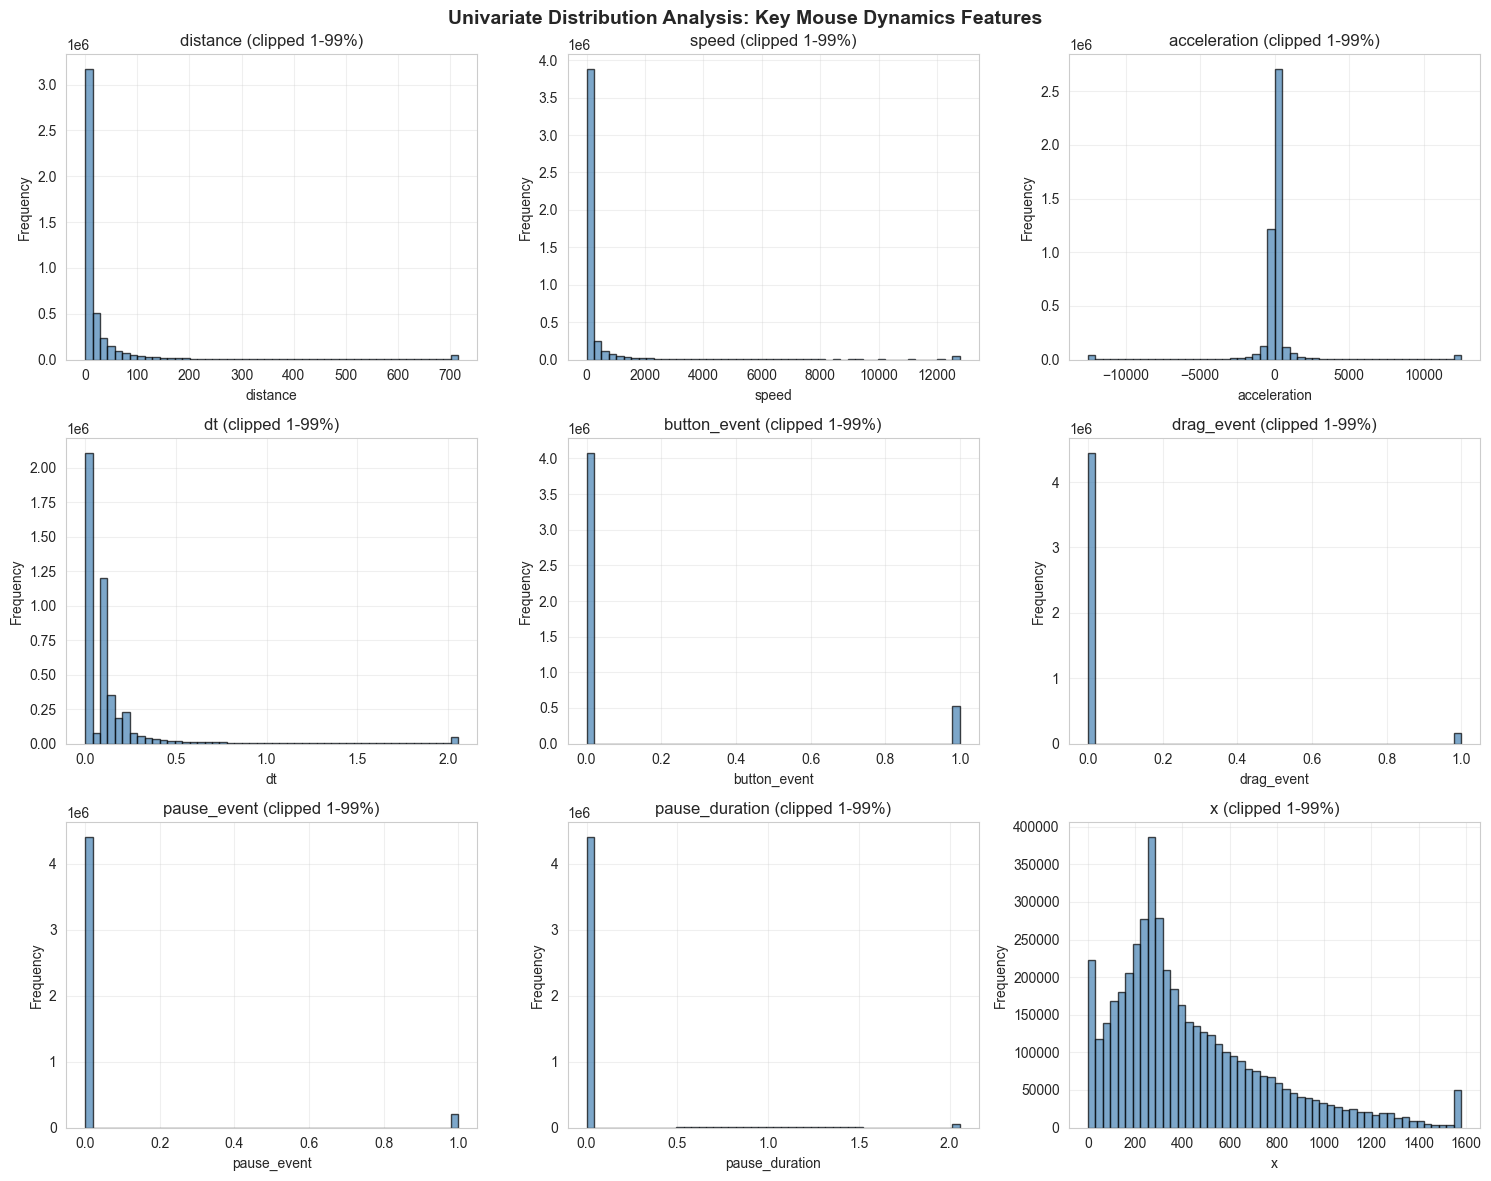

Univariate distributions saved!


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Univariate Distribution Analysis: Key Mouse Dynamics Features', fontsize=14, fontweight='bold')

# Plot distributions for key features
features_to_plot = ['distance', 'speed', 'acceleration', 'dt', 'button_event', 'drag_event', 'pause_event', 'pause_duration', 'x']

for idx, feature in enumerate(features_to_plot):
    ax = axes.flatten()[idx]
    
    # Handle large values with clipping for visualization
    data = events[feature].dropna()
    
    # Use percentile-based clipping for better visualization
    if len(data) > 0:
        p1, p99 = np.percentile(data, [1, 99])
        data_clipped = data.clip(p1, p99)
        
        ax.hist(data_clipped, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_xlabel(feature)
        ax.set_ylabel('Frequency')
        ax.set_title(f'{feature} (clipped 1-99%)')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / '01_univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Univariate distributions saved!")


## Section 6: Univariate Distribution Analysis

Plot distributions for key mouse dynamics metrics.


In [5]:
# Compute additional derived features for deeper analysis
events['acceleration'] = events.groupby('session_id')['speed'].diff().fillna(0)
events['pause_event'] = (events['dt'] > 0.5).astype(int)
events['pause_duration'] = events['dt'] * events['pause_event']

print("CORE MOUSE DYNAMICS FEATURES")
print("=" * 80)

feature_stats = pd.DataFrame({
    'Feature': ['distance', 'speed', 'acceleration', 'dt (time delta)', 'button_event', 'drag_event', 'pressed_event', 'released_event', 'pause_event', 'pause_duration'],
    'Min': [
        events['distance'].min(),
        events['speed'].min(),
        events['acceleration'].min(),
        events['dt'].min(),
        events['button_event'].min(),
        events['drag_event'].min(),
        events['pressed_event'].min(),
        events['released_event'].min(),
        events['pause_event'].min(),
        events['pause_duration'].min()
    ],
    'Mean': [
        events['distance'].mean(),
        events['speed'].mean(),
        events['acceleration'].mean(),
        events['dt'].mean(),
        events['button_event'].mean(),
        events['drag_event'].mean(),
        events['pressed_event'].mean(),
        events['released_event'].mean(),
        events['pause_event'].mean(),
        events['pause_duration'].mean()
    ],
    'Median': [
        events['distance'].median(),
        events['speed'].median(),
        events['acceleration'].median(),
        events['dt'].median(),
        events['button_event'].median(),
        events['drag_event'].median(),
        events['pressed_event'].median(),
        events['released_event'].median(),
        events['pause_event'].median(),
        events['pause_duration'].median()
    ],
    'Max': [
        events['distance'].max(),
        events['speed'].max(),
        events['acceleration'].max(),
        events['dt'].max(),
        events['button_event'].max(),
        events['drag_event'].max(),
        events['pressed_event'].max(),
        events['released_event'].max(),
        events['pause_event'].max(),
        events['pause_duration'].max()
    ],
    'Std': [
        events['distance'].std(),
        events['speed'].std(),
        events['acceleration'].std(),
        events['dt'].std(),
        events['button_event'].std(),
        events['drag_event'].std(),
        events['pressed_event'].std(),
        events['released_event'].std(),
        events['pause_event'].std(),
        events['pause_duration'].std()
    ]
})

print(feature_stats.to_string(index=False))
feature_stats.to_csv(OUTPUT_DIR / 'tables' / 'feature_statistics.csv', index=False)


CORE MOUSE DYNAMICS FEATURES
        Feature           Min        Mean   Median          Max           Std
       distance  0.000000e+00   46.117811 5.099020 9.263878e+04    971.188126
          speed  0.000000e+00 2842.131165 0.978474 9.237600e+07 308650.128226
   acceleration -9.237599e+07    0.095274 0.000000 9.237510e+07 436464.915463
dt (time delta)  0.000000e+00    0.335716 0.100000 3.338199e+04     23.342047
   button_event  0.000000e+00    0.115588 0.000000 1.000000e+00      0.319730
     drag_event  0.000000e+00    0.035794 0.000000 1.000000e+00      0.185775
  pressed_event  0.000000e+00    0.038930 0.000000 1.000000e+00      0.193427
 released_event  0.000000e+00    0.038929 0.000000 1.000000e+00      0.193426
    pause_event  0.000000e+00    0.043581 0.000000 1.000000e+00      0.204160
 pause_duration  0.000000e+00    0.258242 0.000000 3.338199e+04     23.342710


## Section 5: Mouse Dynamics Features Overview

Examine computed behavioral features: speed, acceleration, pause patterns, click intervals, and drag duration.


In [9]:
print("CLEANING AND VALIDATION REPORT")
print("=" * 80)

initial_rows = len(events)

# Check duplicates
duplicates = events.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check coordinate validity
invalid_coords = events[(events['x'] < 0) | (events['y'] < 0)].shape[0]
print(f"Rows with invalid coordinates (x<0 or y<0): {invalid_coords}")

# Check timestamp validity
invalid_time = events[events['record_timestamp'] < 0].shape[0]
print(f"Rows with negative record_timestamp: {invalid_time}")

# Verify timestamps are monotonic per session
print("\nTemporal consistency check per session:")
non_monotonic_sessions = 0
for session_id in events['session_id'].unique():
    session_events = events[events['session_id'] == session_id]
    if not session_events['record_timestamp'].is_monotonic_increasing:
        non_monotonic_sessions += 1

print(f"Sessions with non-monotonic timestamps: {non_monotonic_sessions}")

# Check speed validity (should be non-negative after processing)
invalid_speed = (events['speed'] < 0).sum()
print(f"Rows with negative speed: {invalid_speed}")

# Verify feature completeness
print(f"\nFeature completeness:")
feature_cols = ['distance', 'speed', 'button_event', 'drag_event', 'pressed_event', 'released_event']
for col in feature_cols:
    null_count = events[col].isnull().sum()
    print(f"  {col}: {null_count} nulls")

print(f"\nDataset retained {len(events)}/{initial_rows} rows after processing")


CLEANING AND VALIDATION REPORT
Duplicate rows: 23141
Rows with invalid coordinates (x<0 or y<0): 0
Rows with negative record_timestamp: 0

Temporal consistency check per session:
Sessions with non-monotonic timestamps: 0
Rows with negative speed: 0

Feature completeness:
  distance: 0 nulls
  speed: 0 nulls
  button_event: 0 nulls
  drag_event: 0 nulls
  pressed_event: 0 nulls
  released_event: 0 nulls

Dataset retained 4609929/4609929 rows after processing


## Section 4: Validate and Clean Event Data

Check for duplicates, invalid events, and temporal consistency.


In [4]:
# Event-level data structure
print("=" * 80)
print("EVENT-LEVEL DATA STRUCTURE")
print("=" * 80)
print(f"\nData Types:\n{events.dtypes}")
print(f"\nMissing Values:\n{events.isnull().sum()}")
print(f"\nDataFrame Info:")
events.info()

print("\n" + "=" * 80)
print("UNIQUE IDENTIFIERS")
print("=" * 80)
print(f"Unique users: {events['user_id'].nunique()}")
print(f"Unique sessions: {events['session_id'].nunique()}")
print(f"Unique button states: {events['button'].nunique()}")
print(f"Unique states: {events['state'].nunique()}")

print(f"\nUsers: {sorted(events['user_id'].unique())}")
print(f"\nSplits: {events['split'].unique()}")

print("\n" + "=" * 80)
print("SESSION-LEVEL DATA STRUCTURE")
print("=" * 80)
print(f"\nData Types:\n{sessions.dtypes}")
print(f"\nMissing Values:\n{sessions.isnull().sum()}")


EVENT-LEVEL DATA STRUCTURE

Data Types:
record_timestamp    float64
client_timestamp    float64
button                  str
state                   str
x                     int64
y                     int64
dx                  float64
dy                  float64
dt                  float64
distance            float64
speed               float64
button_event          int64
drag_event            int64
pressed_event         int64
released_event        int64
split                   str
user_id                 str
session_id              str
is_illegal          float64
dtype: object

Missing Values:
record_timestamp          0
client_timestamp          0
button                    0
state                     0
x                         0
y                         0
dx                        0
dy                        0
dt                        0
distance                  0
speed                     0
button_event              0
drag_event                0
pressed_event             0
relea

## Section 3: Inspect Dataset Structure and Data Types

Examine schema, data types, missing values, and unique identifiers.


In [3]:
# Load processed mouse dynamics data
events_file = DATA_PROCESSED / 'mouse_events.csv'
summary_file = DATA_PROCESSED / 'mouse_events_session_summary.csv'

print(f"Loading events from: {events_file}")
print(f"Loading summary from: {summary_file}")

events = pd.read_csv(events_file)
sessions = pd.read_csv(summary_file)

print(f"\nEvents shape: {events.shape}")
print(f"Sessions shape: {sessions.shape}")
print(f"\nFirst few rows of events:")
print(events.head())
print(f"\nFirst few rows of sessions:")
print(sessions.head())


Loading events from: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\data\processed\mouse_dynamics\mouse_events.csv
Loading summary from: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\data\processed\mouse_dynamics\mouse_events_session_summary.csv

Events shape: (4609929, 19)
Sessions shape: (1676, 10)

First few rows of events:
   record_timestamp  client_timestamp    button state     x    y    dx   dy  \
0             0.000             0.000  NoButton  Move  1043  410   0.0  0.0   
1             0.232             0.094  NoButton  Move  1024  410 -19.0  0.0   
2             0.232             0.094  NoButton  Move  1019  410  -5.0  0.0   
3             0.232             0.234  NoButton  Move   979  409 -40.0 -1.0   
4             0.342             0.234  NoButton  Move   974  411  -5.0  2.0   

      dt   distance      speed  button_event  drag_event  pressed_event  \
0  0.000   0.000000   0.000000             0           0              

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Configure plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully")


Libraries imported successfully


## Section 2: Import Libraries and Load Data

Load mouse dynamics event and session summary datasets.


In [1]:
from pathlib import Path
import sys

# Add parent directory to path for imports
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
sys.path.insert(0, str(project_root / 'src'))

# Define data paths (relative to project root)
DATA_RAW = project_root / 'data' / 'raw' / 'mouse_dynamics_challenge'
DATA_PROCESSED = project_root / 'data' / 'processed' / 'mouse_dynamics'
OUTPUT_DIR = project_root / 'notebooks' / 'eda_outputs'

# Create output directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)
(OUTPUT_DIR / 'tables').mkdir(exist_ok=True)

print(f"Project Root: {project_root}")
print(f"Data Processed: {DATA_PROCESSED}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"Processed data exists: {DATA_PROCESSED.exists()}")


Project Root: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform
Data Processed: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\data\processed\mouse_dynamics
Output Directory: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\notebooks\eda_outputs
Processed data exists: True


## Section 1: Setup and Configuration

Configure paths, create output directories, and set notebook parameters.


# Mouse Dynamics Exploratory Data Analysis

This notebook performs comprehensive EDA on the Balabit Mouse Dynamics Challenge dataset, processed through the ml-agentic-platform pipeline.

**Dataset Overview:**
- **Challenge**: Behavioral biometric authentication via mouse dynamics
- **Task**: Detect illegal account usage by analyzing mouse movement patterns
- **Source**: Training files (legitimate sessions) + Test files (mixed legitimate/illegal)
- **Labeling**: Public labels for test sessions; training assumed legitimate
